In [1]:
import numpy as np
import pandas as pd
import math

In [3]:
# import synthetic landscape

data_folder = 'sfield/'

lscape_name_notxt = 'dipplane45_45_posdip_fee30_7_13_17_A_1MCstrongxvyvssB1_dyn'

img_folder = 'sfimgs/' + lscape_name_notxt + '/'

synscape = pd.read_csv(data_folder + lscape_name_notxt + '.txt', sep=' ')
print(synscape.shape)
print(synscape.columns)

(9604, 21)
Index(['x,', 'y,', 'z,', 'sig1,', 'sig2,', 'sig3,', 'S1-x,', 'S1-y,', 'S1-z,',
       'S2-x,', 'S2-y,', 'S2-z,', 'S3-x,', 'S3-y,', 'S3-z,', 'sxx,', 'sxy,',
       'sxz,', 'syy,', 'syz,', 'szz'],
      dtype='object')


In [4]:
# remove commas from column names
synscape.columns = synscape.columns.str.replace(',', '', regex=False)

In [5]:
# set EVA parameters
# EVA - Every-direction Variogram Anisotropy
# from dissertation by Sam Roy (2015), Ch.5
eva_scales = list(range(1, 11)) # separation distances [1, 2, ..., 10]
angles_deg = list(range(0, 180, 5))  # angles in degrees [0, 5, 10, ..., 170, 175]
vc2 = 25 # a stabilizer for division -- can be DEM error range -- setting to 1/2 grid size for now

In [6]:
# clean up grid

x_grid = np.linspace(synscape['x'].min(), synscape['x'].max(), 98)
y_grid = np.linspace(synscape['y'].min(), synscape['y'].max(), 98)

from scipy.interpolate import griddata

xx, yy = np.meshgrid(x_grid, y_grid)
z_grid = griddata(
    points=synscape[['x','y']].values,
    values=synscape['z'].values,
    xi=(xx,yy),
    method='cubic'
)

print(z_grid.shape)

(98, 98)


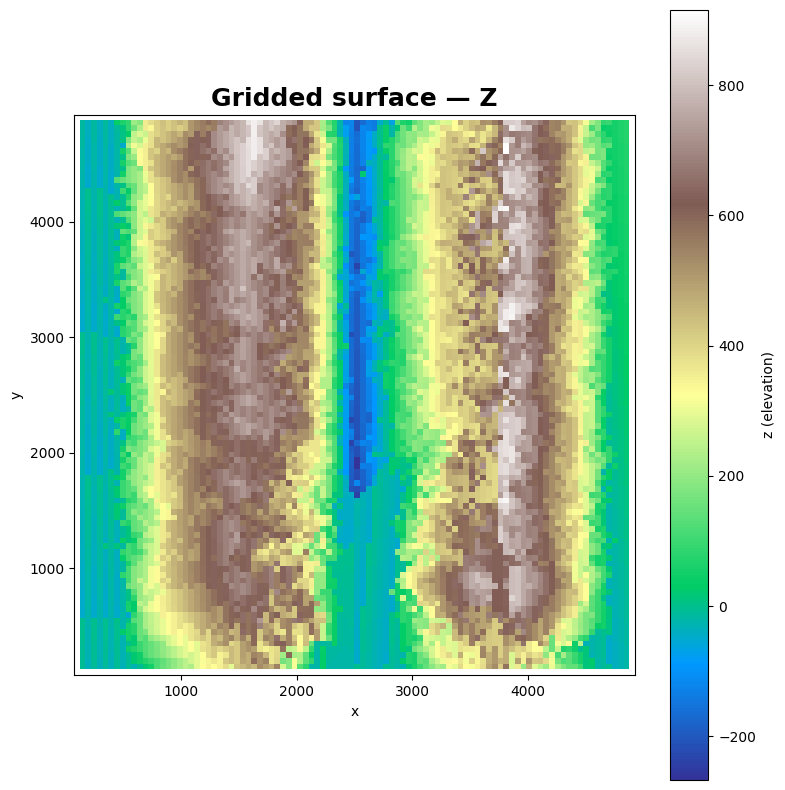

In [23]:
# plot z_grid to check

import matplotlib.pyplot as plt

grid_tag = 'gridplot_'

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(z_grid, cmap='terrain', origin='lower',
               extent=[synscape['x'].min(), synscape['x'].max(), synscape['y'].min(), synscape['y'].max()])
plt.colorbar(im, ax=ax, label='z (elevation)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Gridded surface — Z', fontsize=18, fontweight='bold')
plt.tight_layout()
# plt.savefig(img_folder + grid_tag + lscape_name_notxt + '.png')
plt.show()

In [8]:
# build separate grid with sigmaxx only

sxx_grid = griddata(
    points=synscape[['x','y']].values,
    values=synscape['sxx'].values,
    xi=(xx,yy),
    method='cubic'
)

print(sxx_grid.shape)

(98, 98)


In [9]:
# and for sigmayy

syy_grid = griddata(
    points=synscape[['x','y']].values,
    values=synscape['syy'].values,
    xi=(xx,yy),
    method='cubic'
)

print(syy_grid.shape)

(98, 98)


In [10]:
# and for szz

szz_grid = griddata(
    points=synscape[['x','y']].values,
    values=synscape['szz'].values,
    xi=(xx,yy),
    method='cubic'
)

print(szz_grid.shape)

(98, 98)


In [11]:
# and for sxy

sxy_grid = griddata(
    points=synscape[['x','y']].values,
    values=synscape['sxy'].values,
    xi=(xx,yy),
    method='cubic'
)

print(sxy_grid.shape)

(98, 98)


In [12]:
# and for syz

syz_grid = griddata(
    points=synscape[['x','y']].values,
    values=synscape['syz'].values,
    xi=(xx,yy),
    method='cubic'
)

print(syz_grid.shape)

(98, 98)


In [13]:
# and for strength stress

sxz_grid = griddata(
    points=synscape[['x','y']].values,
    values=synscape['sxz'].values,
    xi=(xx,yy),
    method='cubic'
)

print(sxz_grid.shape)

(98, 98)


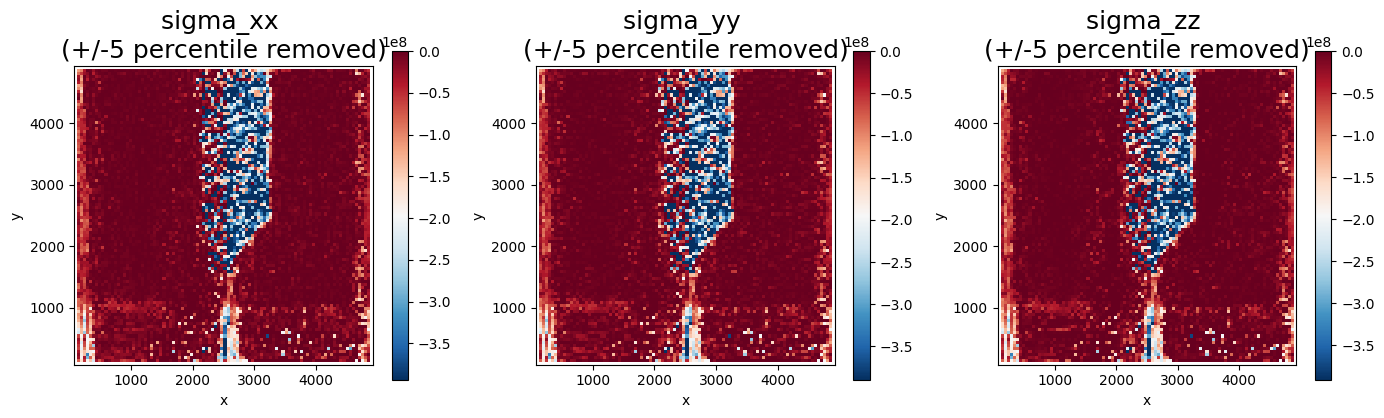

In [25]:
# plot sxx, syy, szz 

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

normals_tag = 'normals_'

for ax, arr, name in zip(axes,
                         [sxx_grid, syy_grid, szz_grid],
                         ['sigma_xx \n(+/-5 percentile removed)', 
                          'sigma_yy \n(+/-5 percentile removed)',
                          'sigma_zz \n(+/-5 percentile removed)']):
    vmin, vmax = np.nanpercentile(arr, [5, 95])
    #print(f"{name}: 2nd pct={vmin:.4f}, 98th pct={vmax:.4f}")
    im = ax.imshow(arr, cmap='RdBu_r', origin='lower',
                   vmin=vmin, vmax=vmax,
                   extent=[synscape['x'].min(), synscape['x'].max(),
                                synscape['y'].min(), synscape['y'].max()])
    plt.colorbar(im, ax=ax, shrink=0.7)
    ax.set_title(name, fontsize=18)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
# plt.savefig(img_folder + normals_tag + lscape_name_notxt + '.png')
plt.show()

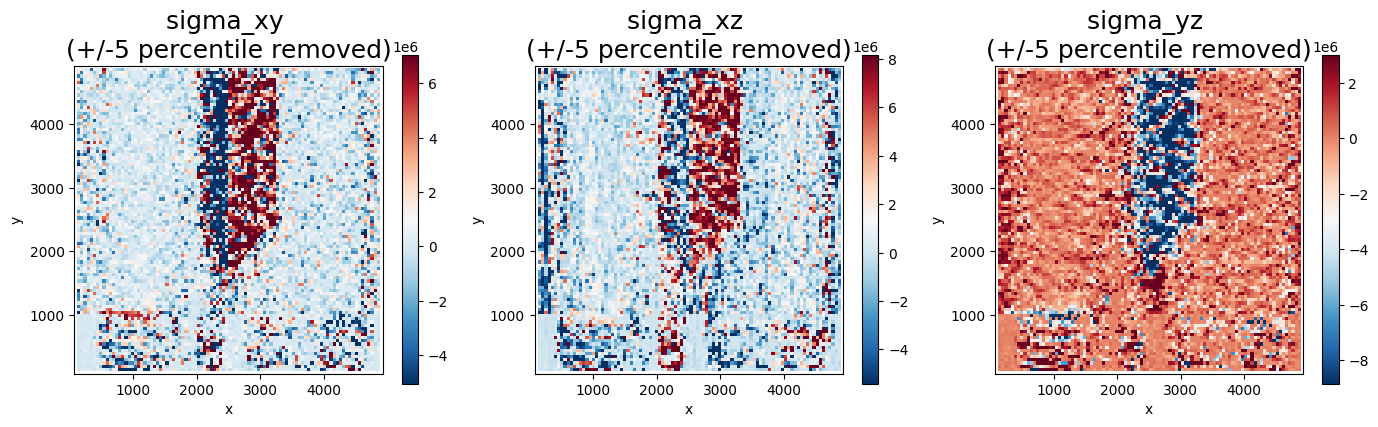

In [27]:
# plot shear stresses

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

shears_tag = 'shears_'

for ax, arr, name in zip(axes,
                         [sxy_grid, sxz_grid, syz_grid],
                         ['sigma_xy \n(+/-5 percentile removed)', 
                          'sigma_xz \n(+/-5 percentile removed)',
                          'sigma_yz \n(+/-5 percentile removed)']):
    vmin, vmax = np.nanpercentile(arr, [5, 95])
    #print(f"{name}: 2nd pct={vmin:.4f}, 98th pct={vmax:.4f}")
    im = ax.imshow(arr, cmap='RdBu_r', origin='lower',
                   vmin=vmin, vmax=vmax,
                   extent=[synscape['x'].min(), synscape['x'].max(),
                                synscape['y'].min(), synscape['y'].max()])
    plt.colorbar(im, ax=ax, shrink=0.7)
    ax.set_title(name, fontsize=18)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
# plt.savefig(img_folder + shears_tag + lscape_name_notxt + '.png')
plt.show()

In [16]:
# begin processing topographic features

In [17]:
from scipy.ndimage import sobel, generic_gradient_magnitude
import numpy as np

# grid resolution
res = (synscape['x'].max() - synscape['x'].min()) / z_grid.shape[0] - 1 # assuming square grid

In [18]:
# first derivatives (gradients)
dz_dy = sobel(z_grid, axis=0) / (8 * res)
dz_dx = sobel(z_grid, axis=1) / (8 * res)

# slope (degrees)
slope = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))

print('slope calculated')
print(slope[:5,:5]) # verify contents filling

slope calculated
[[       nan        nan        nan        nan        nan]
 [       nan        nan        nan        nan        nan]
 [       nan        nan 1.30124516 1.36354133 1.40120075]
 [       nan        nan 1.29657962 1.30577608 1.31366189]
 [       nan        nan 1.18825473 1.14125359 1.16938015]]


In [19]:
# aspect (degrees, 0=north, clockwise)

aspect = np.arctan2(-dz_dx, dz_dy) % 2*np.pi

sinasp = np.sin(aspect)
cosasp = np.cos(aspect)

print("aspect, sinasp, cosasp calculated")
print(sinasp[:5,:5])
print(cosasp[:5,:5])

aspect, sinasp, cosasp calculated
[[        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [        nan         nan  0.32084592 -0.65840618 -0.10560834]
 [        nan         nan  0.21335292 -0.62564846 -0.41008178]
 [        nan         nan  0.20181955 -0.49875368 -0.72326015]]
[[       nan        nan        nan        nan        nan]
 [       nan        nan        nan        nan        nan]
 [       nan        nan 0.9471314  0.75266281 0.9944078 ]
 [       nan        nan 0.97697519 0.78010512 0.91204875]
 [       nan        nan 0.97942272 0.86674377 0.69057566]]


In [20]:
# curvatures via second derivatives
d2z_dx2 = np.gradient(np.gradient(z_grid, axis=1), axis=1) / res**2
d2z_dy2 = np.gradient(np.gradient(z_grid, axis=0), axis=0) / res**2
d2z_dxdy = np.gradient(np.gradient(z_grid, axis=0), axis=1) / res**2

# profile curvature (in direction of slope)
# k_p = (fxxfx^2 + 2fxyfxfy + fyyfy^2) / ((fx^2 + fy^2)^(3/2))
prof_curv = -((dz_dx**2 * d2z_dx2) + (2*dz_dx*dz_dy*d2z_dxdy) + (dz_dy**2 * d2z_dy2)) / \
                ((dz_dx**2 + dz_dy**2)**1.5 + 1e-10)

plan_curv = (dz_dx**2 * d2z_dy2 - 2*dz_dx*dz_dy*d2z_dxdy + dz_dy**2 * d2z_dx2) / \
                ((dz_dx**2 + dz_dy**2)**1.5 + 1e-10)

print('profile and planar curvatures calculated')

profile and planar curvatures calculated


In [21]:
# sanity check
for name, arr in zip(['slope','aspect','sinasp','cosasp','prof_curv','plan_curv'],
                     [slope, aspect, sinasp, cosasp, prof_curv, plan_curv]):
    print(f"{name}: min={np.nanmin(arr):.5f}, max={np.nanmax(arr):.5f}, mean={np.nanmean(arr):.3f}")

slope: min=0.41556, max=78.20202, mean=37.218
aspect: min=0.00065, max=6.28298, mean=3.166
sinasp: min=-1.00000, max=1.00000, mean=-0.001
cosasp: min=-1.00000, max=1.00000, mean=0.036
prof_curv: min=-0.65510, max=1.59728, mean=-0.001
plan_curv: min=-1.61645, max=1.23413, mean=0.000


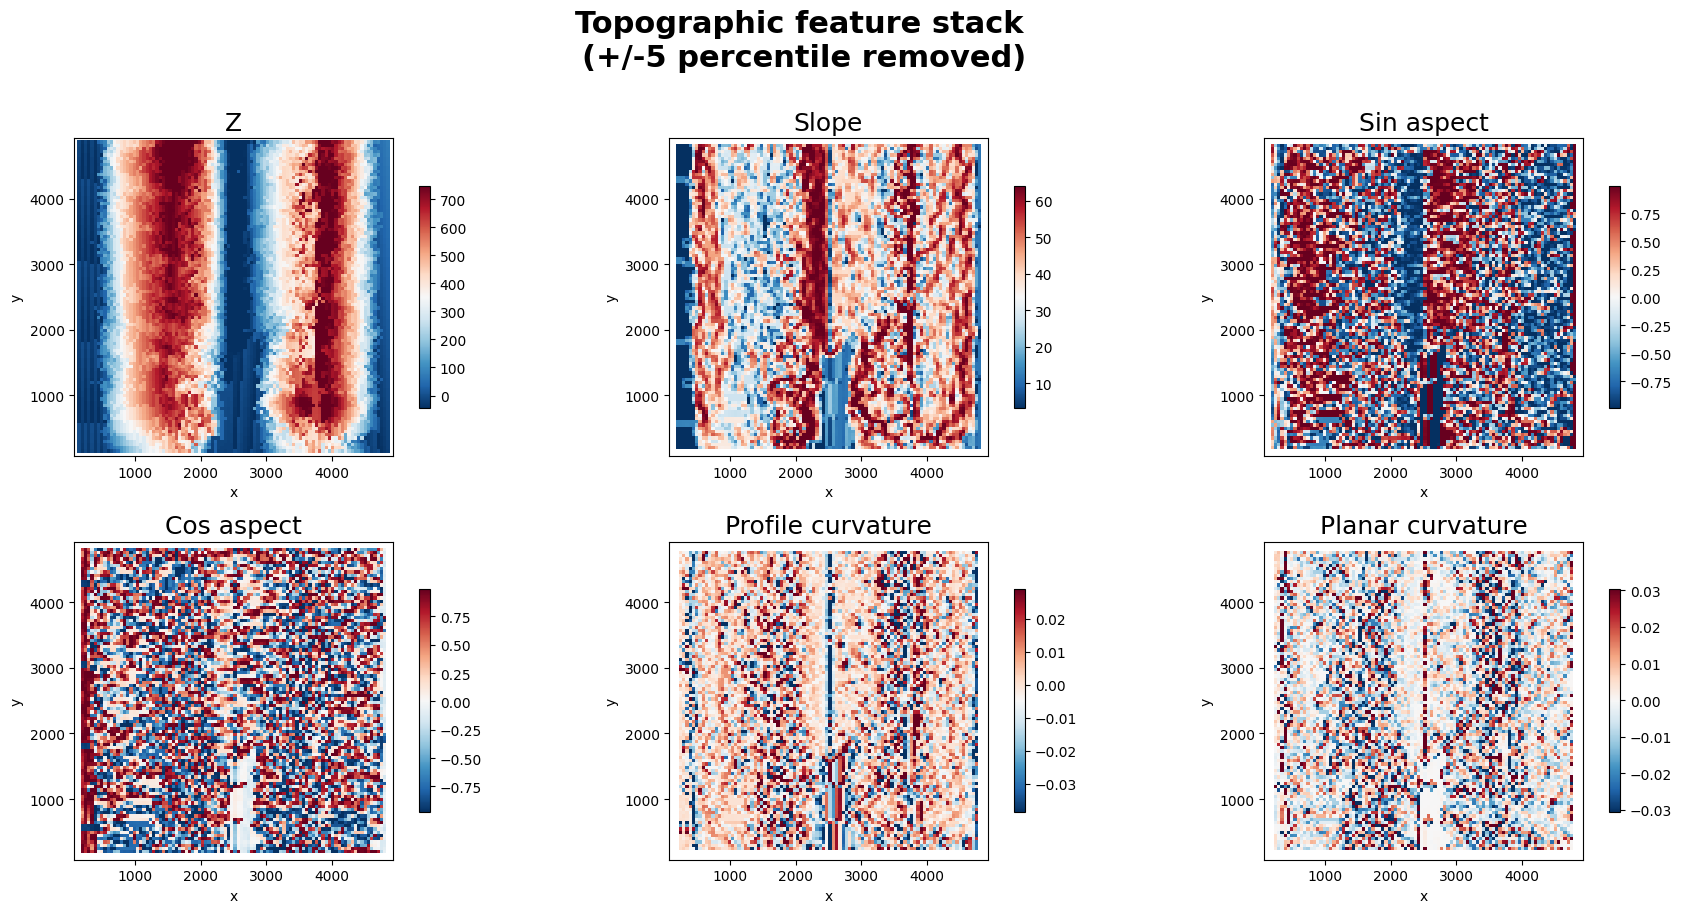

In [29]:
# plot topographic features
import matplotlib.pyplot as plt

topo_tag = 'topos_'

features = {
    'Z': z_grid,
    'Slope': slope,
    'Sin aspect': sinasp,
    'Cos aspect': cosasp,
    'Profile curvature': prof_curv,
    'Planar curvature': plan_curv
}

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, (name, arr) in enumerate(features.items()):
    vmin, vmax = np.nanpercentile(arr, [5, 95])
    im = axes[i].imshow(arr, cmap='terrain' if name == 'z' else 'RdBu_r',
                        vmin=vmin, vmax=vmax,
                        origin='lower',
                        extent=[synscape['x'].min(), synscape['x'].max(),
                                synscape['y'].min(), synscape['y'].max()])
    plt.colorbar(im, ax=axes[i], shrink=0.7)
    axes[i].set_title(name, fontsize=18)
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')

# hide the empty 8th panel
#axes[-2].set_visible(False)

plt.suptitle('Topographic feature stack \n(+/-5 percentile removed)', fontsize=22, weight='bold', y=1.01)
plt.tight_layout()
# plt.savefig(img_folder + topo_tag + lscape_name_notxt + '.png')

plt.show()

In [30]:
# prepare for anisotropy calculations

In [31]:
def round_half_away(x):
    """Round half away from zero — conventional rounding for all signs."""
    eps = 1e-9 # handles floating point imprecision at halfway points
    return int(math.floor(abs(x) + 0.5 + eps) * (1 if x >= 0 else -1))

In [32]:
def var_raw(z, i, j, t, phi_deg):
    """
    Raw squared elevation difference at point (i,j)
    - for separation distance t in direction phi_deg from horizontal
    - averaged with opposite direction
    - equation 5.1 from Roy (2015), applied in both directions
    - returns 0 if either neighbor is out of bounds
    """
    # using round_half_away
    # because python rounds 0.5 to 0.0, we want 1.0
    phi_rad = math.radians(phi_deg)
    di = round_half_away(t * math.sin(phi_rad))
    dj = round_half_away(t * math.cos(phi_rad))
    
    #print(f"  phi={phi_deg}, t={t}: raw_di={raw_di:.6f}, raw_dj={raw_dj:.6f}, di={di}, dj={dj}")
    #print(f'phi={phi_deg}, t={t}, di={di}, dj={dj}')
    i_fwd, i_bwd = i + di, i - di
    j_fwd, j_bwd = j + dj, j - dj

    # bounds check
    if (i_fwd < 0 or i_fwd >= z.shape[0] or
        i_bwd < 0 or i_bwd >= z.shape[0] or
        j_fwd < 0 or j_fwd >= z.shape[1] or
        j_bwd < 0 or j_bwd >= z.shape[1]):
        return 0.0

    v_fwd = (z[i,j] - z[i_fwd, j_fwd]) ** 2
    v_bwd = (z[i,j] - z[i_bwd, j_bwd]) ** 2

    return v_fwd + v_bwd

In [33]:
def var_cumulative(z, i, j, s, phi_deg):
    """
    Cumulative averaged variance up to separation distance s
    for angle phi_deg, averaging forward and backward directions.
    Equation 5.3 from Roy (2015).
    """
    accumulator = 0.0
    for t in range(1, s+1):
        accumulator += var_raw(z, i, j, t, phi_deg)

    return accumulator / (2 * s)

In [34]:
def compute_anisotropy(z, i, j, angles_deg, scales, vc2):
    """
    Compute anisotropy magnitude and orientation 
    at point (i,j) for all scales.
    Returns anis_mag and anis_phi arrays of length len(scales).
    Equation 5.4 from Roy (2015).
    """
    n_scales = len(scales)
    n_angles = len(angles_deg)
    angle_step = angles_deg[1] - angles_deg[0] # assumes uniform spacing

    anis_mag = np.zeros(n_scales)
    anis_phimins = np.zeros(n_scales)

    for s_idx, s in enumerate(scales):
        raw_anis = {}
        # compute cumulative variance for all angles at this scale
        for phi in angles_deg:
            raw_anis[phi] = var_cumulative(z, i, j, s, phi)

        # find angle of minimum variance
        phi_min = min(raw_anis, key=raw_anis.get)
        
        # orthogonal angle -- wrap within angle array
        phi_orth = (phi_min + 90) % 180
    
        # check phi_orth is in raw array(?), snap to nearest if not
        if phi_orth not in raw_anis:
            phi_orth = min(angles_deg, key=lambda x: abs(x - phi_orth))
        
        anis_mag[s_idx] = (vc2 + raw_anis[phi_orth]) / (vc2 + raw_anis[phi_min])
        anis_phimins[s_idx] = phi_min
        
    return anis_mag, anis_phimins

In [35]:
def compute_eva(z, angles_deg, scales, vc2):
    """
    Compute EVA anisotropy for all interior points of grid z.
    Interior defined as points at least max(scales) from the border.
    Returns anis_mag and anis_phi arrays of shape (nrows, ncols, n_scales).
    """
    nrows, ncols = z.shape
    n_scales = len(scales)
    pad = max(scales)

    eva_mag = np.zeros((nrows, ncols, n_scales))
    # start with nan to avoid confusing original 0.0 with 0-degree phi_min
    eva_phi = np.full((nrows, ncols, n_scales), np.nan)

    for i in range(pad, nrows - pad):
        for j in range(pad, ncols - pad):
            mag, phi = compute_anisotropy(z, i, j, angles_deg, scales, vc2)
            eva_mag[i, j, :] = mag
            eva_phi[i, j, :] = phi

    return eva_mag, eva_phi

In [36]:
# run EVA calculation on full z-grid
evamag_syn, evaphi_syn = compute_eva(z_grid, angles_deg, eva_scales, vc2)

print(f"output shape: {evamag_syn.shape}")
print(f"interior points computed: {(~np.isnan(evaphi_syn[:,:,0])).sum()}")
print(f"eva_mag1 range: {np.nanmin(evamag_syn):.4f} to {np.nanmax(evamag_syn):.4f}")
print(f"eva_phi1 unique values: {np.unique(evaphi_syn[~np.isnan(evaphi_syn)])}")

output shape: (98, 98, 10)
interior points computed: 6084
eva_mag1 range: 0.0000 to 3931.3719
eva_phi1 unique values: [  0.   5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.  65.
  70.  75.  80.  85.  90.  95. 100. 105. 110. 115. 120. 125. 130. 135.
 140. 145. 150. 155. 160. 165. 170. 175.]


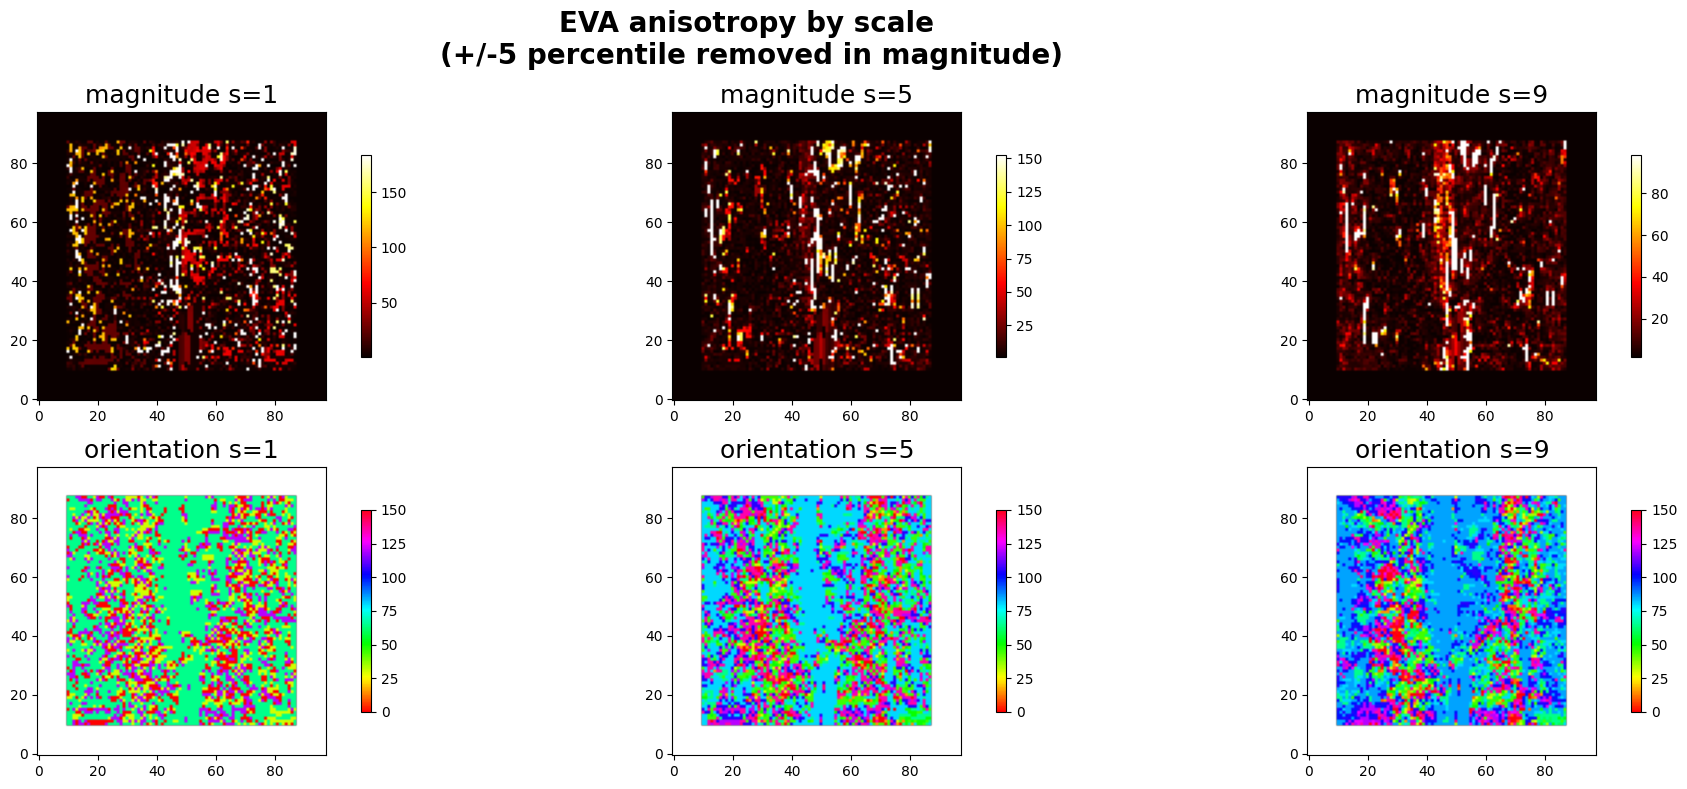

In [37]:
# plot anisotropy

anis_tag = 'anis_'

fig, axes = plt.subplots(2, 3, figsize=(20, 8))

for s_idx, s in enumerate(eva_scales[::4]):
    # anisotropy magnitude
    arr_mag = evamag_syn[:, :, s_idx]
    vmin, vmax = np.nanpercentile(arr_mag[arr_mag != 0], [5, 95])
    im = axes[0, s_idx].imshow(arr_mag, cmap='hot', origin='lower',
                                vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=axes[0, s_idx], shrink=0.7)
    axes[0, s_idx].set_title(f'magnitude s={s}',fontsize=18)

    # anisotropy orientation
    arr_phi = evaphi_syn[:, :, s_idx].copy()
    # arr_phi[arr_phi == 360] = np.nan  # mask uncomputed points
    im = axes[1, s_idx].imshow(arr_phi, cmap='hsv', origin='lower',
                                vmin=0, vmax=150)
    plt.colorbar(im, ax=axes[1, s_idx], shrink=0.7)
    axes[1, s_idx].set_title(f'orientation s={s}', fontsize=18)

plt.suptitle('EVA anisotropy by scale \n(+/-5 percentile removed in magnitude)', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(img_folder + anis_tag + lscape_name_notxt + '.png')
plt.show()

In [38]:
# crop pixels from all sides to remove nans
# and set topo features even with anisotropy extent
crop = max(eva_scales) + 1

z_c         = z_grid[crop:-crop, crop:-crop]
slope_c     = slope[crop:-crop, crop:-crop]
aspect_c    = aspect[crop:-crop, crop:-crop]
sinasp_c    = sinasp[crop:-crop, crop:-crop]
cosasp_c    = cosasp[crop:-crop, crop:-crop]
prof_curv_c = prof_curv[crop:-crop, crop:-crop]
plan_curv_c = plan_curv[crop:-crop, crop:-crop]
evaphi_c    = evaphi_syn[crop:-crop, crop:-crop]
evamag_c    = evamag_syn[crop:-crop, crop:-crop]


# verify no remaining NaNs and all shapes aligned
for name, arr in zip(['z','slope','sinasp','cosasp','prof_curv','plan_curv','evaphi_c','evamag_c'],
                     [z_c, slope_c, sinasp_c, cosasp_c, prof_curv_c, plan_curv_c, evaphi_c, evamag_c]):
    print(f"{name}: NaNs={np.isnan(arr).sum()}")
    print(f"{name}: Shape={arr.shape}")

z: NaNs=0
z: Shape=(76, 76)
slope: NaNs=0
slope: Shape=(76, 76)
sinasp: NaNs=0
sinasp: Shape=(76, 76)
cosasp: NaNs=0
cosasp: Shape=(76, 76)
prof_curv: NaNs=0
prof_curv: Shape=(76, 76)
plan_curv: NaNs=0
plan_curv: Shape=(76, 76)
evaphi_c: NaNs=0
evaphi_c: Shape=(76, 76, 10)
evamag_c: NaNs=0
evamag_c: Shape=(76, 76, 10)


In [39]:
# stack topo and anis features
import numpy as np
# stack features into (n_pixels, n_features)
# taking anisotropy values at separations s=1,5,10
feature_stack = np.stack([
    z_c, slope_c, sinasp_c, cosasp_c, prof_curv_c, plan_curv_c, 
    evaphi_c[:,:,0], evamag_c[:,:,0],
    evaphi_c[:,:,4], evamag_c[:,:,4],
    evaphi_c[:,:,9], evamag_c[:,:,9]
], axis=-1)
print('features stacked')

features stacked


In [40]:
# reshape for PCA only


n_rows, n_cols, n_features = feature_stack.shape
X = feature_stack.reshape(-1, n_features)
print(f'feature matrix shape: {X.shape}')

feature matrix shape: (5776, 12)


In [41]:
# standardize for PCA only
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('scaled')

scaled


In [42]:
# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
print('pcaed')

pcaed


In [43]:
# explained variance
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f} ({var*100:.1f}%) -- cumulative: {pca.explained_variance_ratio_[:i+1].sum()*100:.1f}%")

PC1: 0.1623 (16.2%) -- cumulative: 16.2%
PC2: 0.1241 (12.4%) -- cumulative: 28.6%
PC3: 0.1103 (11.0%) -- cumulative: 39.7%
PC4: 0.1013 (10.1%) -- cumulative: 49.8%
PC5: 0.0857 (8.6%) -- cumulative: 58.4%
PC6: 0.0829 (8.3%) -- cumulative: 66.7%
PC7: 0.0779 (7.8%) -- cumulative: 74.5%
PC8: 0.0733 (7.3%) -- cumulative: 81.8%
PC9: 0.0615 (6.1%) -- cumulative: 87.9%
PC10: 0.0501 (5.0%) -- cumulative: 92.9%
PC11: 0.0373 (3.7%) -- cumulative: 96.7%
PC12: 0.0333 (3.3%) -- cumulative: 100.0%


In [44]:
# examine PCA loadings for correlation
import pandas as pd

feature_names_topo = ['z', 'slope', 'sin_aspect', 'cos_aspect', 'prof_curv', 'plan_curv',
                 'evaphi_1','evamag_1','evaphi_5','evamag_5','evaphi_10','evamag_10']

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names_topo,
    columns=[f'PC{i+1}' for i in range(12)]
).round(3)

print(loadings)

              PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8    PC9  \
z          -0.443  0.022  0.055 -0.272 -0.063 -0.137 -0.168  0.517 -0.114   
slope      -0.043  0.364 -0.198  0.565 -0.174 -0.104  0.100 -0.382  0.114   
sin_aspect  0.003 -0.028  0.220  0.110  0.834  0.296 -0.218 -0.178 -0.119   
cos_aspect  0.035  0.076 -0.212  0.163 -0.134  0.838  0.253  0.366 -0.035   
prof_curv  -0.376 -0.508 -0.168  0.225 -0.024  0.032  0.009 -0.137  0.041   
plan_curv   0.311  0.580  0.185 -0.177  0.016 -0.020  0.000  0.089  0.006   
evaphi_1    0.033 -0.087  0.323  0.342  0.183 -0.300  0.683  0.307 -0.291   
evamag_1    0.041  0.117 -0.111  0.572  0.060 -0.172 -0.542  0.477 -0.015   
evaphi_5   -0.032 -0.118  0.629  0.143 -0.130  0.118 -0.027  0.091  0.725   
evamag_5    0.522 -0.313 -0.064  0.051 -0.055 -0.048 -0.124  0.092 -0.035   
evaphi_10  -0.024 -0.057  0.530  0.134 -0.434  0.199 -0.269 -0.224 -0.588   
evamag_10   0.534 -0.360 -0.072 -0.030 -0.078 -0.050 -0.035  0.078  0.013   

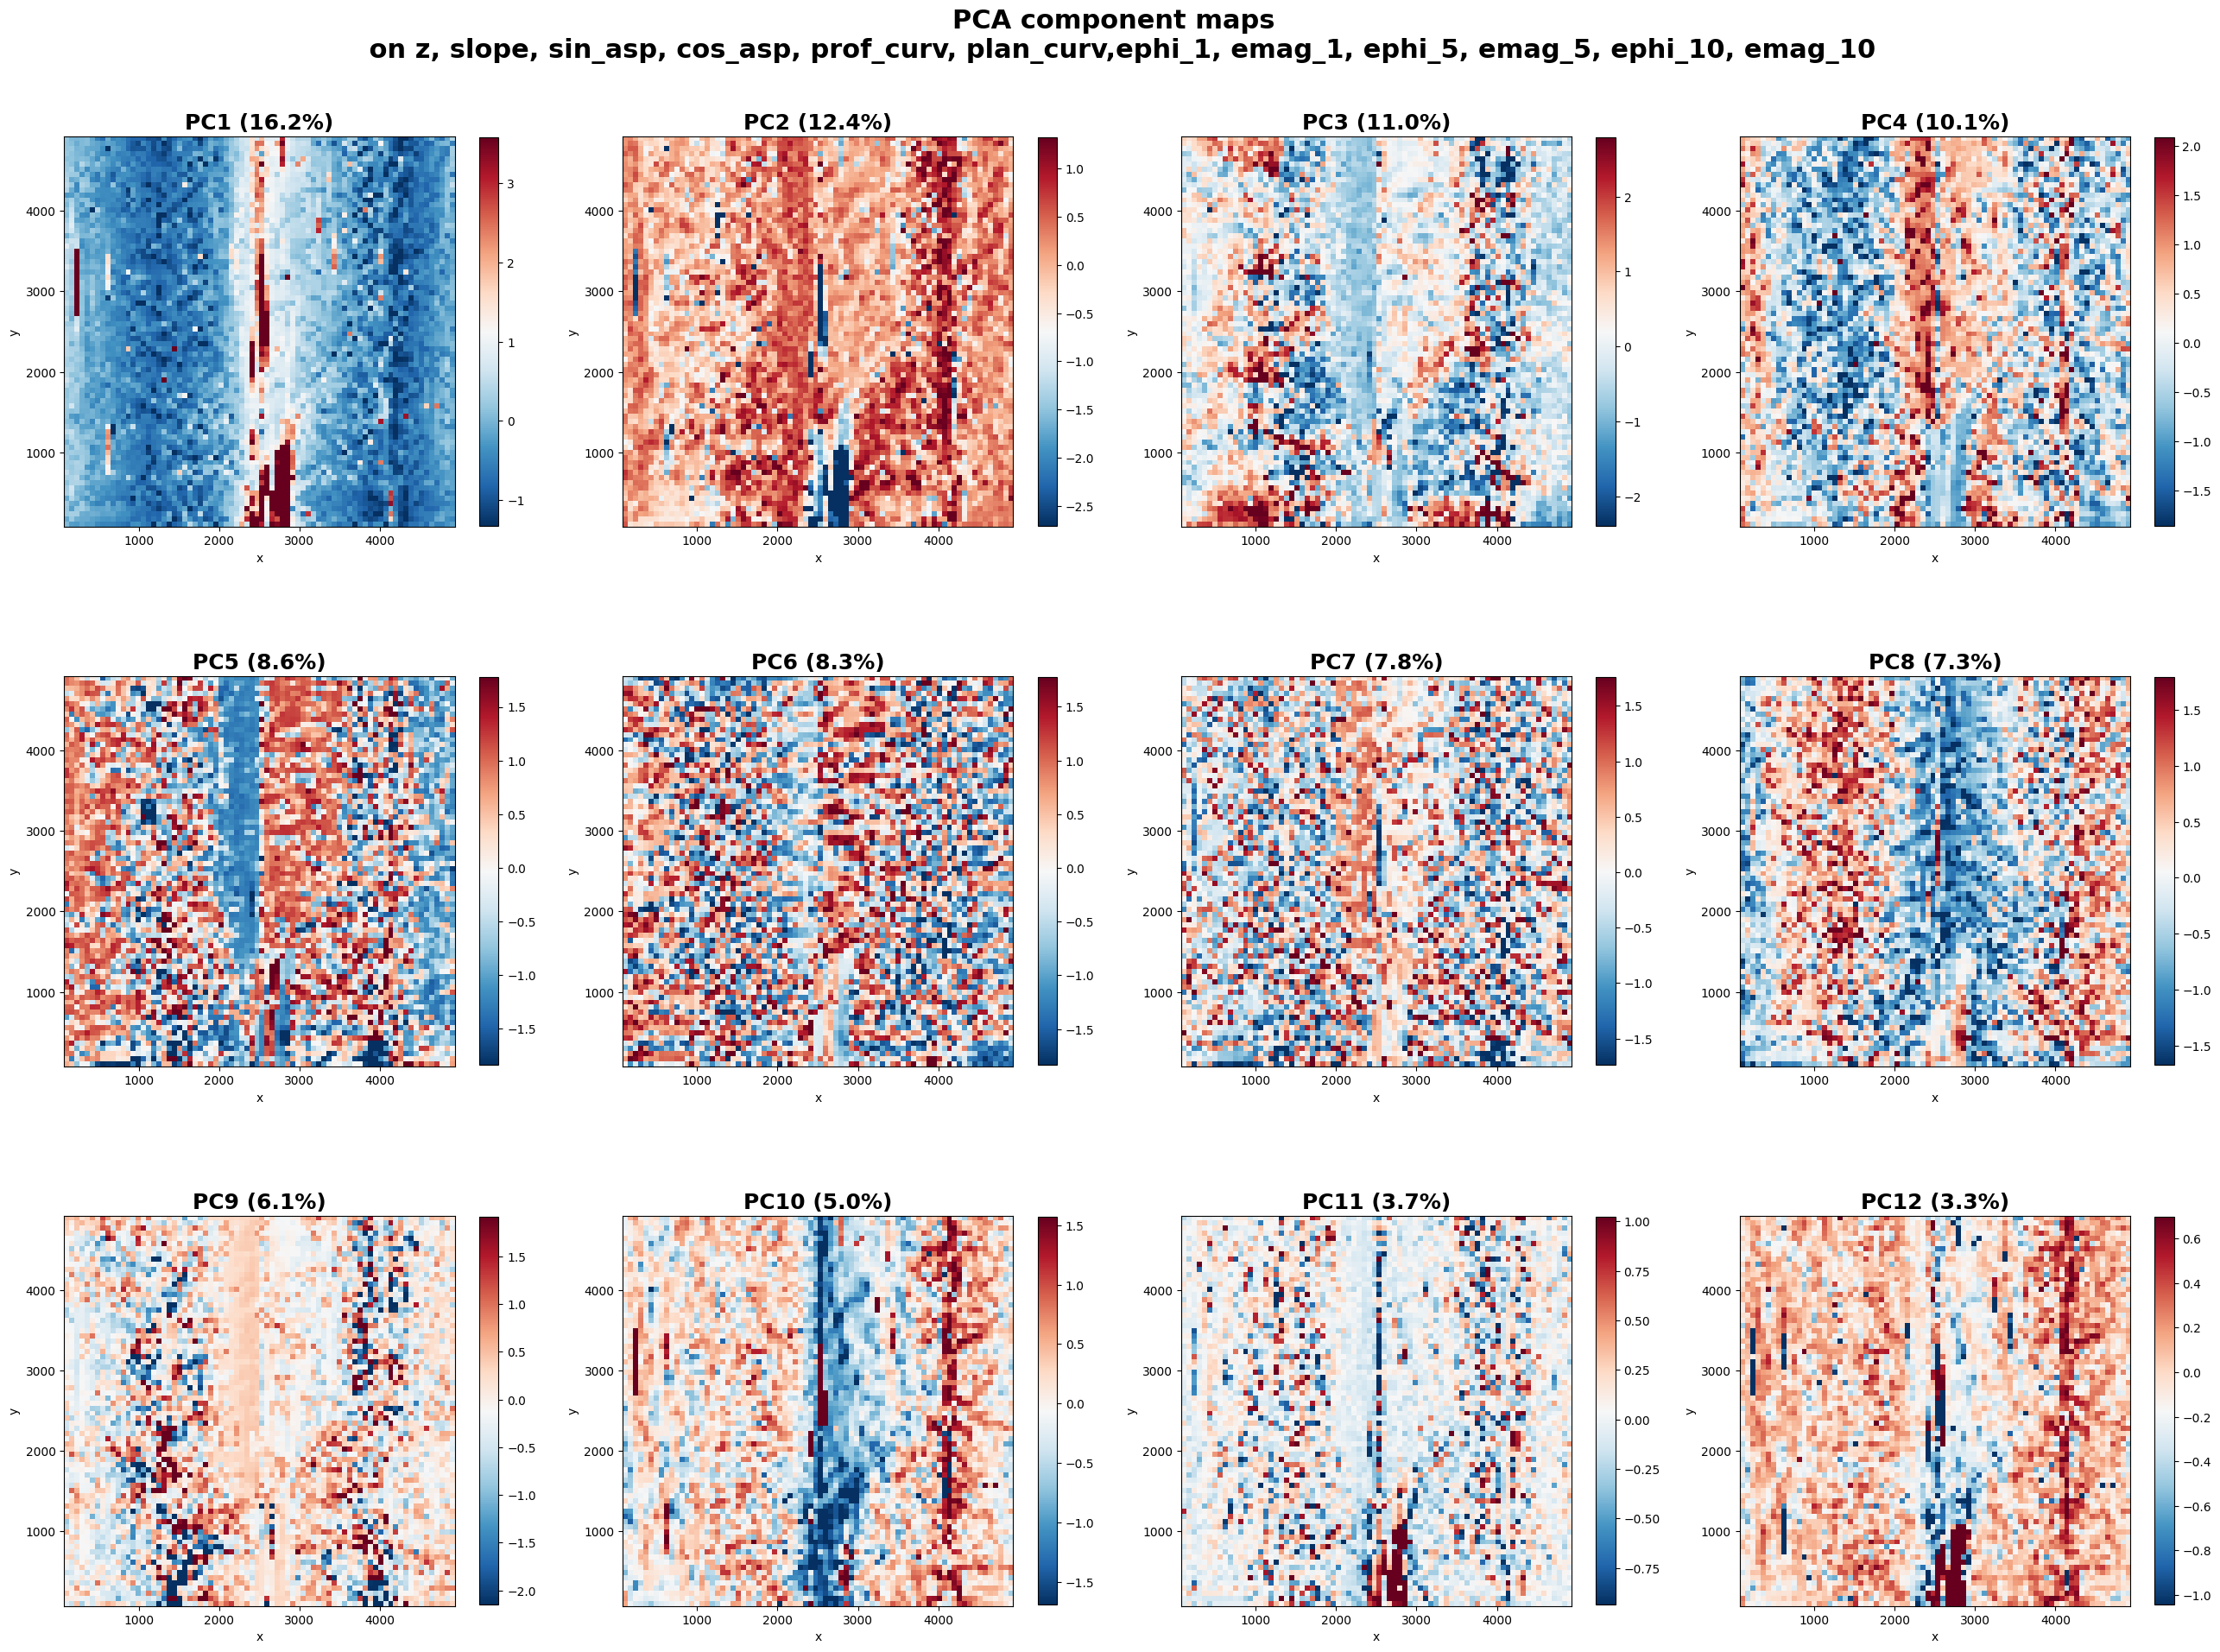

In [47]:
# reshape PC scores back to spatial grid
X_pca_grid = X_pca.reshape(n_rows, n_cols, 12)

pca_tag = 'pca_'

fig, axes = plt.subplots(3, 4, figsize=(26, 20))
axes = axes.flatten()

for i in range(12):
    arr = X_pca_grid[:, :, i]
    vmin, vmax = np.nanpercentile(arr, [2, 98])
    im = axes[i].imshow(arr, cmap='RdBu_r', origin='lower',
                        vmin=vmin, vmax=vmax,
                        extent=[synscape['x'].min(), synscape['x'].max(),
                                synscape['y'].min(), synscape['y'].max()])
    plt.colorbar(im, ax=axes[i], shrink=0.7)
    axes[i].set_title(f'PC{i+1} ({pca.explained_variance_ratio_[i]*100:.1f}%)', fontsize=18, fontweight='bold')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')

plt.suptitle('PCA component maps \n on z, slope, sin_asp, cos_asp, prof_curv, plan_curv,ephi_1, emag_1, ephi_5, emag_5, ephi_10, emag_10', 
             fontsize=22, fontweight='bold')
plt.tight_layout()
# plt.savefig(img_folder + pca_tag + lscape_name_notxt + '.png')
plt.show()

In [48]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from datetime import date

# --- labeling ---
pdf_tag = 'pca_res_'
pdf_path = img_folder + pdf_tag + lscape_name_notxt + '.pdf'
# ------------------------

feature_names = ['z', 'slope', 'sin_aspect', 'cos_aspect', 'prof_curv', 'plan_curv',
                 'evaphi_1', 'evamag_1', 'evaphi_5', 'evamag_5', 'evaphi_10', 'evamag_10']

n_components = len(pca.explained_variance_ratio_)
pc_labels = [f'PC{i+1}' for i in range(n_components)]
cumvar = pca.explained_variance_ratio_.cumsum()
loadings = pca.components_.T  # (n_features, n_components)

# find top 3 loading indices per PC column
top3_per_pc = [
    set(np.argsort(np.abs(loadings[:, j]))[-3:])
    for j in range(n_components)
]

with PdfPages(pdf_path) as pdf:

    # --- page 1: variance table ---
    fig, ax = plt.subplots(figsize=(8.5, 4))
    ax.axis('off')

    table_data = [[pc,
                   f'{v:.4f}',
                   f'{v*100:.1f}%',
                   f'{c*100:.1f}%']
                  for pc, v, c in zip(pc_labels,
                                      pca.explained_variance_ratio_,
                                      cumvar)]

    tbl = ax.table(
        cellText=table_data,
        colLabels=['Component', 'Variance', 'Individual %', 'Cumulative %'],
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.2, 1.6)

    # style header
    for j in range(4):
        tbl[0, j].set_facecolor('steelblue')
        tbl[0, j].set_text_props(color='white', fontweight='bold')

    # highlight cumulative >= 90%
    for i, c in enumerate(cumvar):
        if c >= 0.90:
            for j in range(4):
                tbl[i+1, j].set_facecolor('#f0f0f0')

    ax.set_title(lscape_name_notxt + '\n— PCA explained variance —',
                 fontsize=12, pad=15, fontweight='bold')
    fig.text(0.5, 0.02, f'Generated: {date.today()}',
             ha='center', fontsize=8, color='gray')

    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # --- page 2: loadings table ---
    fig, ax = plt.subplots(figsize=(18, 6))
    ax.axis('off')

    table_data = []
    for i, feat in enumerate(feature_names):
        row = [feat] + [f'{loadings[i, j]:.3f}' for j in range(n_components)]
        table_data.append(row)

    tbl = ax.table(
        cellText=table_data,
        colLabels=['Feature'] + pc_labels,
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)
    tbl.scale(1, 1.6)

    # style header
    for j in range(n_components + 1):
        tbl[0, j].set_facecolor('steelblue')
        tbl[0, j].set_text_props(color='white', fontweight='bold')

    # highlight top 3 per PC in red bold
    for j in range(n_components):
        for i in top3_per_pc[j]:
            cell = tbl[i+1, j+1]  # +1 offset for header row and feature col
            cell.set_text_props(color='firebrick', fontweight='bold')

    ax.set_title(lscape_name_notxt + '\n— PCA loadings (top 3 per component in red) —',
                 fontsize=12, pad=15, fontweight='bold')
    fig.text(0.5, 0.02, f'Generated: {date.today()}',
             ha='center', fontsize=8, color='gray')

    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # --- page 3: variance bar chart ---
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(n_components)
    ax.bar(x, pca.explained_variance_ratio_ * 100,
           color='steelblue', alpha=0.8, label='Individual')
    ax.plot(x, cumvar * 100, 'o-', color='firebrick',
            linewidth=1.5, markersize=4, label='Cumulative')
    ax.axhline(90, color='gray', linestyle='--',
               linewidth=0.8, alpha=0.7, label='90% threshold')
    ax.set_xticks(x)
    ax.set_xticklabels(pc_labels, fontsize=9)
    ax.set_ylabel('Explained variance (%)')
    ax.set_title(lscape_name_notxt + '\n— PCA explained variance by component —',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 105)
    fig.text(0.5, 0.02, f'Generated: {date.today()}',
             ha='center', fontsize=8, color='gray')

    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

print(f"saved: {pdf_path}")

saved: sfimgs/dipplane45_45_posdip_fee30_7_13_17_A_1MCstrongxvyvssB1_dyn/pca_res_dipplane45_45_posdip_fee30_7_13_17_A_1MCstrongxvyvssB1_dyn.pdf


In [49]:
# crop strengths and failures to anisotropy extent
crop = max(eva_scales) + 1

sxx_c  = sxx_grid[crop:-crop, crop:-crop]
syy_c   = syy_grid[crop:-crop, crop:-crop]
szz_c  = szz_grid[crop:-crop, crop:-crop]
sxy_c = sxy_grid[crop:-crop, crop:-crop]
sxz_c = sxz_grid[crop:-crop, crop:-crop]
syz_c = syz_grid[crop:-crop, crop:-crop]



# verify no remaining NaNs and all shapes aligned
for name, arr in zip(['sxx','syy','szz','sxy','sxz','syz'],
                     [sxx_c, syy_c, szz_c, sxy_c, sxz_c, syz_c]):
    print(f"{name}: NaNs={np.isnan(arr).sum()}")
    print(f"{name}: Shape={arr.shape}")

sxx: NaNs=0
sxx: Shape=(76, 76)
syy: NaNs=0
syy: Shape=(76, 76)
szz: NaNs=0
szz: Shape=(76, 76)
sxy: NaNs=0
sxy: Shape=(76, 76)
sxz: NaNs=0
sxz: Shape=(76, 76)
syz: NaNs=0
syz: Shape=(76, 76)


In [51]:
# stack strengths and failures
import numpy as np

stresses_names = ['sxx','syy','szz','sxy','sxz','syz']
# stack features into (n_pixels, n_features)
# taking anisotropy values at s=1,5,10
stresses_stack = np.stack([sxx_c, syy_c, szz_c, sxy_c, sxz_c, syz_c]
                           , axis=-1)
print('stresses stacked')

stresses stacked


In [52]:
# save topo_anis and stresses arrays, metadata for reference

import numpy as np
import json

data_tag = 'Xy_'
data_path = img_folder + data_tag + lscape_name_notxt

# save arrays
np.savez(data_path + '.npz',
         topo_anis_X=feature_stack,
         stressten_components_y=stresses_stack)
print('arrays saved')

# save metadata
meta = {
    'landscape_file': lscape_name_notxt,
    'topo_anis_features': feature_names_topo,
    'topo_anis_shape': list(feature_stack.shape),
    'stressten_components': stresses_names,
    'stresten_components_shape': list(stresses_stack.shape),
    'date created': str(date.today())
}

# add landscape stats to metadata
for name, arr in zip(['slope','aspect','sinasp','cosasp','prof_curv','plan_curv'],
                     [slope, aspect, sinasp, cosasp, prof_curv, plan_curv]):
    meta[name] = f"{name}: min={np.nanmin(arr):.5f}, max={np.nanmax(arr):.5f}, mean={np.nanmean(arr):.3f}"

    
with open(data_path+'_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print('meta saved')

arrays saved
meta saved


In [53]:
import numpy as np
import json

with np.load(img_folder + 'Xy_' + lscape_name_notxt + '.npz' ) as data:
    # print("Available keys:", data.files)
    topo_anis = data['topo_anis_X']
    stressten_components_y = data['stressten_components_y']

print(topo_anis_X.shape)
print(stressten_components_y.shape)

with open(img_folder + 'Xy_' + lscape_name_notxt + '_meta.json') as f:
    meta = json.load(f)

feature_names_topo = meta['topo_anis_features']
feature_names_failstren = meta['stressten_components']
print(feature_names_topo)
print(feature_names_failstren)

(76, 76, 12)
(76, 76, 6)
['z', 'slope', 'sin_aspect', 'cos_aspect', 'prof_curv', 'plan_curv', 'evaphi_1', 'evamag_1', 'evaphi_5', 'evamag_5', 'evaphi_10', 'evamag_10']
['sxx', 'syy', 'szz', 'sxy', 'sxz', 'syz']
